## Import Packages

In [1]:
import numpy       as np
import pandas      as pd
import matplotlib.pyplot as plt
import pywt

## Load Data

In [2]:
# Load data with column names
path = 'https://github.com/ljwg3000/SummerResearch/blob/master/AI_tutorial/Week_1/ExampleData?raw=true'
Data = pd.read_csv(path, sep=',',names=['time(s)', 'Acceleration(g)', 'Voltage(V)', 'Current(kA)'])
Data

,time(s),Acceleration(g),Voltage(V),Current(kA)
0,0.000000,0.016440,-0.014200,0.001433
1,0.000078,0.013822,-0.015707,0.001504
2,0.000156,0.019431,-0.016963,0.001433
3,0.000234,0.003726,-0.017248,0.001549
4,0.000313,0.022049,-0.009840,0.001864
...,...,...,...,...
2769,0.216330,0.077392,0.002404,0.003453
2770,0.216410,0.030276,0.003952,0.003498
2771,0.216480,0.017188,0.005504,0.003397
2772,0.216560,0.037754,-0.000108,0.003506


Confirm each signal by plotting

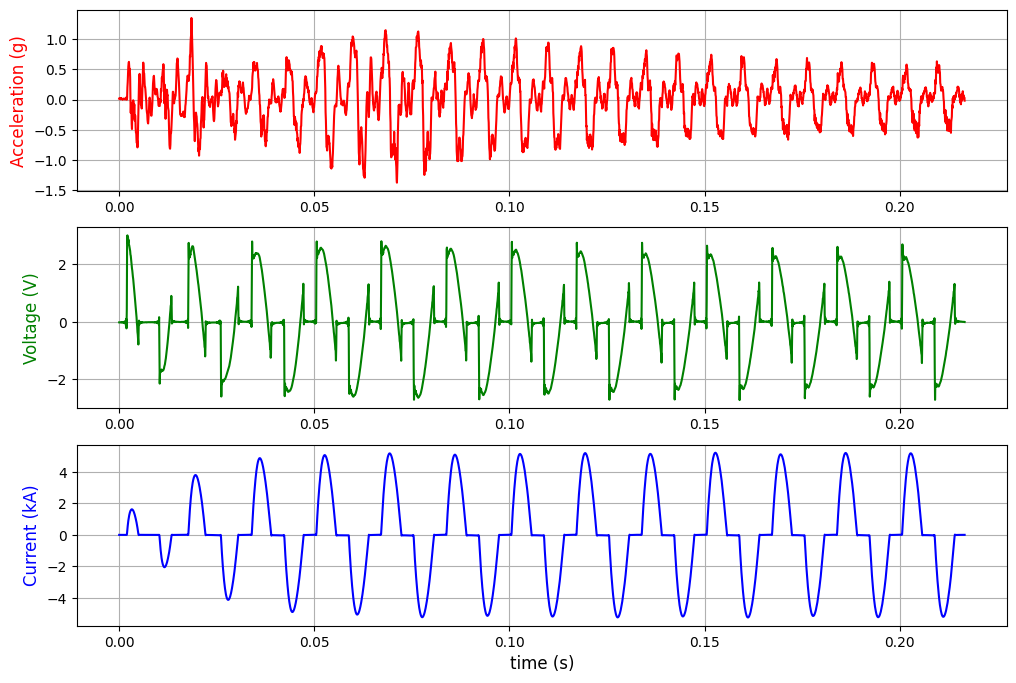

In [3]:
plt.figure(figsize=(12,8))

plt.subplot(3,1,1) # Acceleration signal
plt.plot(Data.iloc[:,0] , Data.iloc[:,1], color='r')
plt.ylabel('Acceleration (g)', fontsize=12, color='r')
plt.grid()

plt.subplot(3,1,2) # Voltage signal
plt.plot(Data.iloc[:,0] , Data.iloc[:,2], color='g')
plt.ylabel('Voltage (V)', fontsize=12, color='g')
plt.grid()

plt.subplot(3,1,3) # Current signal
plt.plot(Data.iloc[:,0] , Data.iloc[:,3], color=[0,0,1])
plt.ylabel('Current (kA)',fontsize=12, color='b')
plt.xlabel('time (s)', fontsize=12)
plt.grid()

plt.show()

.

.

## **Wavelet Transform (WT)-based Signal Decomposition**

### 🔎 Quick Refresher:

- **Why WT?**  
  Unlike FFT (global frequency content) or STFT (fixed time-frequency window),  
  the Wavelet Transform provides **multi-resolution analysis**:  
  - High frequencies → short time windows (good time resolution)  
  - Low frequencies → long time windows (good frequency resolution)  
- This makes WT very powerful for **non-stationary signals**.

---

### (1) Parameter setting for WT

#### **Key Parameters of WT**

- **Mother wavelet**  
  - The prototype wavelet used to generate all scaled/shifted versions.  
  - Examples: `'haar'`, `'db4'`, `'sym5'`, `'coif5'`, `'mexh'` (Mexican hat), `'morl'` (Morlet).  
  - Choice depends on the signal:  
    * `'haar'` → simple step-like signals  
    * `'dbN'` (Daubechies) → smooth engineering signals  
    * `'morl'` → time-frequency analysis with oscillatory nature  
  - To better understand, please find: https://www.mathworks.com/help/wavelet/gs/introduction-to-the-wavelet-families.html
  - Documentation of `PyWt`: https://pywavelets.readthedocs.io/en/latest/ref/wavelets.html

- **Level (decomposition depth)**  
  - How many times the signal is recursively split into approximation/detail parts.  
  - Higher level → captures lower frequency bands.  
  - Limited by signal length (`max_level = log2(N)` approximately).


In [4]:
MotherWavelet = pywt.Wavelet('db4')   # Mother wavelet
Level         = 8                     # Wavelet levels

---

### (2) Wavelet Decomposition Implementation

#### **Coefficients from Decomposition**

- `pywt.wavedec()` returns a list of coefficient arrays:  
  * Approximation (`a`) → low-frequency content  
  * Details (`d`) → high-frequency content at each level  

In [5]:
Data_Target = Data.iloc[:,2] # Select one sensor signal
Coefficient = pywt.wavedec(Data_Target, MotherWavelet, level=Level, axis=0)
len(Coefficient)

9

In [6]:
# Confirm extracted coefficients as DataFrame
Coefficient_df = pd.DataFrame(Coefficient)
Coefficient_df

,0,1,2,3,4,5,6,7,8,9,...,1380,1381,1382,1383,1384,1385,1386,1387,1388,1389
0,0.082200,-0.194631,0.101005,0.339425,-0.932158,2.151891,2.349834,0.640869,-0.351165,-0.764656,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.066563,-0.051562,-2.916762,-2.424665,8.871959,9.700314,-3.438204,-11.064069,-3.368313,8.278569,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,-0.030951,-0.221169,-2.803817,0.453991,6.643282,-11.822918,12.916048,-6.857005,-4.014167,13.243865,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,-0.010202,0.010597,-0.396609,5.696939,2.980666,4.867398,7.071993,-1.706438,-1.588702,-2.604986,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.005150,0.003482,0.423509,1.368434,-4.940334,2.131953,1.722882,-1.336164,-0.816409,-2.903883,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,-0.000307,-0.000841,0.012792,-0.151526,3.528499,-1.515508,-0.339669,0.233981,-0.142921,0.080567,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,0.001290,0.003912,-0.002701,0.010293,0.365247,1.274355,-1.131834,0.136128,0.068044,0.080120,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,0.001046,0.003607,0.000098,-0.002928,0.003174,0.000206,-0.020104,-0.727722,1.027516,-0.432596,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,-0.000398,-0.000246,0.004131,-0.004075,-0.010752,0.004743,0.000926,0.021518,0.025883,0.010263,...,-0.001312,0.002248,0.000123,-0.000498,-0.000397,0.00095,-0.002956,0.000914,0.002603,-0.00198


Confirm the sizes of each coefficient
* Time resolution gets higher for observing high frequency signals

In [7]:
print('Size of a',Level, ' = ', len(Coefficient[0]))  # First coefficient : the lowest freqeuncy ragne

for i in range(1,Level+1):
    print('Size of d',Level+1-i , ' = ', len(Coefficient[i]))

Size of a 8  =  17
Size of d 8  =  17
Size of d 7  =  28
Size of d 6  =  50
Size of d 5  =  93
Size of d 4  =  179
Size of d 3  =  352
Size of d 2  =  698
Size of d 1  =  1390


- **Why different sizes?**  
  - Each decomposition step downsamples the signal by 2.  
  - So, higher-frequency detail signals have **finer time resolution** (more samples).  
  - Lower-frequency approximation signals have **fewer samples**.  

👉 This explains why in the code, `len(Coefficient[i])` decreases as the level increases.

.

---

### (3) Plotting of Wavelet Decompositiobn Result


- The raw signal is shown at the top.  
- Below, each subplot shows one coefficient (low-pass approximation or high-pass detail).  
- X-axis is adjusted to match the time duration of each coefficient.  
- Together, the plots illustrate how the signal energy is distributed across different frequency ranges.  


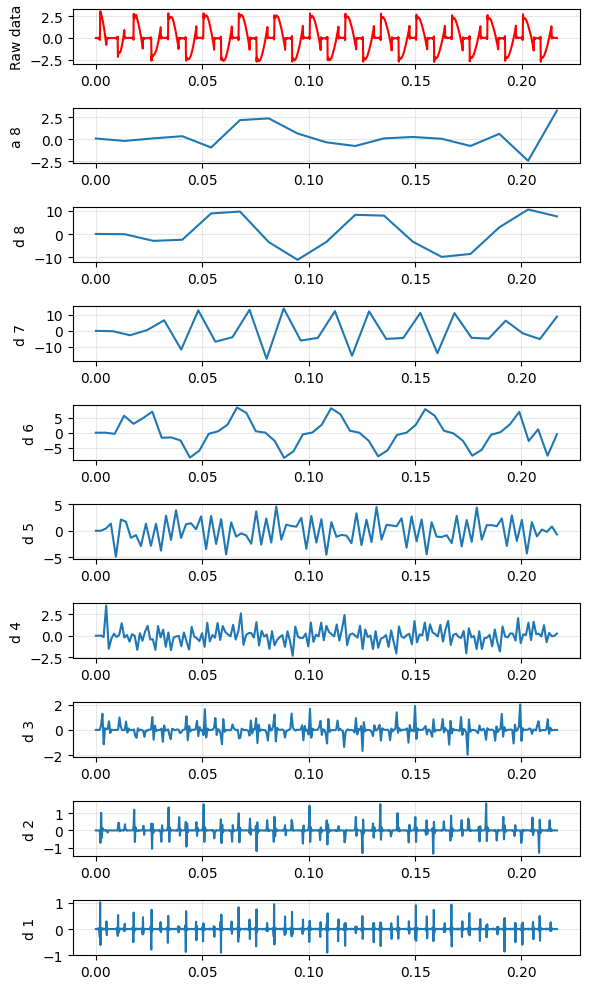

In [8]:
plt.figure(figsize=(6,10))

plt.subplot(Level+2,1,1)    # Raw signal
plt.plot(Data.iloc[:,0], Data_Target, color='r')
plt.ylabel('Raw data')
plt.grid(alpha=0.3)

plt.subplot(Level+2,1,2)    # The lowest frequency range
Time_temp = np.arange( 0 , 0.2167 + 0.2167/(len(Coefficient[0])-1) , 0.2167/(len(Coefficient[0])-1) )
plt.plot(Time_temp , Coefficient[0])
plt.ylabel('a %d' %(Level))
plt.grid(alpha=0.3)

for k in range(1,Level+1):
    plt.subplot(Level+2,1,k+2)
    Time_temp = np.arange( 0 , 0.2167 + 0.2167/(len(Coefficient[k])-1) , 0.2167/(len(Coefficient[k])-1) )
    plt.plot(Time_temp , Coefficient[k])
    plt.ylabel('d %d'%(Level+1-k))
    plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()